# UDD ablation wiring — end-to-end verification (no GPU needed)

This notebook checks that the **public-data ablation changes** work as intended before any GPU is
spent, exercising the real scripts (not reimplementations):

1. corpus + new schema sanity (native `instructions`/`answers` lists, `fold`, derived columns)
2. equal-N trainset build (7 tasks incl. grounding-format localization + derived A2 rationales)
3. arm composition dry-run (the 13 A1–A4 mixes) + **leakage check** (no heldout image in any arm)
4. A2 factor inspection: rationale-chain vs answer-only control on the same record
5. mock multi-model evaluation through the real metric dispatch (sanity: oracle≈1, constant≈0)
6. *(GPU-gated)* actually run the A1/A2 arms

Prerequisite: the merged corpus at `data/udd/hf/_all` (build with
`python scripts/build_udd.py --per-bench 200`).

In [1]:
import json, subprocess, sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from datasets import load_from_disk
from collections import Counter
ds = load_from_disk(str(ROOT / "data/udd/hf/_all"))
print(f"corpus: {len(ds)} image-rows, {len(ds.column_names)} columns")
assert "instructions" in ds.column_names and "qas_json" not in ds.column_names
print("tasks:", dict(Counter(ds["task"]).most_common()))
print("fold:", dict(Counter(ds["fold"])))
print("languages:", dict(Counter(ds["language"]).most_common(6)))
multi = sum(1 for q in ds["instructions"] if len(q) > 1)
print(f"multi-QA image-rows: {multi} (native lists; pairing enforced at build)")
from docvlm_eval.unified.hf import validate_payload_shapes
validate_payload_shapes(ds); print("validate_payload_shapes: PASS")

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


corpus: 6319 image-rows, 22 columns
tasks: {'vqa': 2771, 'reasoning': 1199, 'recognition': 1199, 'localization': 400, 'kie': 350, 'table': 200, 'classification': 200}
fold: {'train': 5716, 'heldout': 603}
languages: {'en': 5301, 'und': 400, 'ar': 201, 'ko': 200, 'zh': 117, 'id': 100}


multi-QA image-rows: 1382 (native lists; pairing enforced at build)


validate_payload_shapes: PASS


## 1. Build the equal-N training sets (tasks + languages + derived A2 pair)

In [2]:
for args in (["--per-task", "300", "--merge-qa", "--derive-spatial-reasoning"],
             ["--out", "data/udd_langs", "--group-by", "language", "--per-task", "300"]):
    r = subprocess.run([sys.executable, "scripts/build_task_trainsets.py", *args],
                       cwd=ROOT, capture_output=True, text=True)
    print(r.stdout[-600:]); assert r.returncode == 0, r.stderr[-500:]

04 used= 300 images=215
[ok]   reasoning      available=4798 used= 300 images=275
[ok]   recognition    available=1095 used= 300 images=300
[ok]   table          available= 174 used= 174 images=174
[ok]   vqa            available=4691 used= 300 images=276
[ok]   heldout: 1178 samples (classification, kie, localization, reasoning, recognition, table, vqa) -> heldout_*.jsonl

=== built 7 per-task sets (N=300 each) -> /home/user/OCR/data/udd_tasks ===
  jsonl : /home/user/OCR/data/udd_tasks/task_<task>.jsonl   (feed to run_task_value.py)
  mixed control  : /home/user/OCR/data/udd_tasks/all.jsonl



142
[ok]   en             available=9512 used= 300 images=287
[ok]   id             available=  89 used=  89 images=89
[ok]   ko             available= 183 used= 183 images=183
[ok]   und            available= 366 used= 300 images=300
[ok]   zh             available= 102 used= 102 images=102
[ok]   heldout: 1178 samples (classification, kie, localization, reasoning, recognition, table, vqa) -> heldout_*.jsonl

=== built 6 per-language sets (N=300 each) -> data/udd_langs ===
  jsonl : data/udd_langs/lang_<language>.jsonl   (feed to run_task_value.py)
  mixed control  : data/udd_langs/all.jsonl



## 2. Compose the 13 ablation arms (dry-run — no training)

In [3]:
r = subprocess.run([sys.executable, "scripts/run_udd_ablation.py",
                    "--arm", "A1", "A2", "A3", "A4", "--count", "300", "--dry-run"],
                   cwd=ROOT, capture_output=True, text=True)
print(r.stdout); assert r.returncode == 0, r.stderr[-500:]

[udd-ablation] 13 arm runs, N=300/arm, heldout=yes

[1/13] A1_spotting_on: 300 samples <- task_vqa.jsonl×0.33 + task_kie.jsonl×0.33 + task_localization.jsonl×0.33
[2/13] A1_spotting_off: 300 samples <- task_vqa.jsonl×0.50 + task_kie.jsonl×0.50
[3/13] A2_reason_chain: 300 samples <- derived_reasoning_chain.jsonl×1.00
[4/13] A2_reason_answer: 300 samples <- derived_reasoning_answer.jsonl×1.00
[5/13] A3_base: 300 samples <- task_vqa.jsonl×0.50 + task_kie.jsonl×0.50
[6/13] A3_spot: 300 samples <- task_vqa.jsonl×0.33 + task_kie.jsonl×0.33 + task_localization.jsonl×0.33
[7/13] A3_reason: 300 samples <- task_vqa.jsonl×0.33 + task_kie.jsonl×0.33 + derived_reasoning_chain.jsonl×0.33
[8/13] A3_spot_reason: 300 samples <- task_vqa.jsonl×0.25 + task_kie.jsonl×0.25 + task_localization.jsonl×0.25 + derived_reasoning_chain.jsonl×0.25
[9/13] A4_en: 300 samples <- lang_en.jsonl×1.00
[10/13] A4_en_ko: 300 samples <- lang_en.jsonl×0.50 + lang_ko.jsonl×0.50
[11/13] A4_en_ar: 300 samples <- lang_en.jsonl×0

## 3. Leakage check — no heldout image may appear in ANY arm's training mix

In [4]:
heldout_imgs = set()
for f in (ROOT / "data/udd_tasks").glob("heldout_*.jsonl"):
    for ln in f.read_text().splitlines():
        heldout_imgs.add(json.loads(ln)["image_path"])
leaks = 0
for arm in sorted((ROOT / "data/udd_tasks/arms").glob("*.jsonl")):
    hit = sum(1 for ln in arm.read_text().splitlines()
              if json.loads(ln)["image_path"] in heldout_imgs)
    print(f"{arm.stem:20} train_rows_using_heldout_images={hit}")
    leaks += hit
assert leaks == 0, f"LEAK: {leaks} heldout images in training arms"
print("leakage check: PASS (fold split is image-keyed and respected by every arm)")

A1_spotting_off      train_rows_using_heldout_images=0
A1_spotting_on       train_rows_using_heldout_images=0
A2_reason_answer     train_rows_using_heldout_images=0
A2_reason_chain      train_rows_using_heldout_images=0
A3_base              train_rows_using_heldout_images=0
A3_reason            train_rows_using_heldout_images=0
A3_spot              train_rows_using_heldout_images=0
A3_spot_reason       train_rows_using_heldout_images=0
A4_en                train_rows_using_heldout_images=0
A4_en_ar             train_rows_using_heldout_images=0
A4_en_id             train_rows_using_heldout_images=0
A4_en_ko             train_rows_using_heldout_images=0
A4_en_zh             train_rows_using_heldout_images=0
leakage check: PASS (fold split is image-keyed and respected by every arm)


## 4. The A2 factor, isolated — rationale chain vs answer-only on the same element

In [5]:
chain = [json.loads(l) for l in (ROOT/"data/udd_tasks/derived_reasoning_chain.jsonl").read_text().splitlines()]
answer = [json.loads(l) for l in (ROOT/"data/udd_tasks/derived_reasoning_answer.jsonl").read_text().splitlines()]
assert len(chain) == len(answer), "A2 arm pair must have identical record counts"
by_id = {r["sample_id"]: r for r in answer}
ex = chain[0]; ctrl = by_id[ex["sample_id"]]
print("SAME element, two targets (the only difference = the rationale text):")
print(f"  chain  Q: {ex['question'][:80]}")
print(f"  chain  A: {ex['answers'][0][:160]}")
print(f"  answer Q: {ctrl['question'][:80]}")
print(f"  answer A: {ctrl['answers'][0][:160]}")

SAME element, two targets (the only difference = the rationale text):
  chain  Q: Where is the B-QUESTION located in the document? Explain how you find it.
  chain  A: Scanning the document layout, the I-QUESTION is a useful anchor. The B-QUESTION appears to the left of the I-QUESTION, in the middle-left of the page, reading '
  answer Q: Where is the B-QUESTION located in the document?
  answer A: The B-QUESTION is in the middle-left of the page.


## 5. Mock multi-model evaluation (real metric dispatch, deterministic models)

[ok] /home/user/OCR/docs/results/udd_mock_eval.md
[ok] /home/user/OCR/docs/report/figures/udd_mock_eval.png
[ok] sanity holds: oracle ~1.0, constant ~0.0 across all tasks



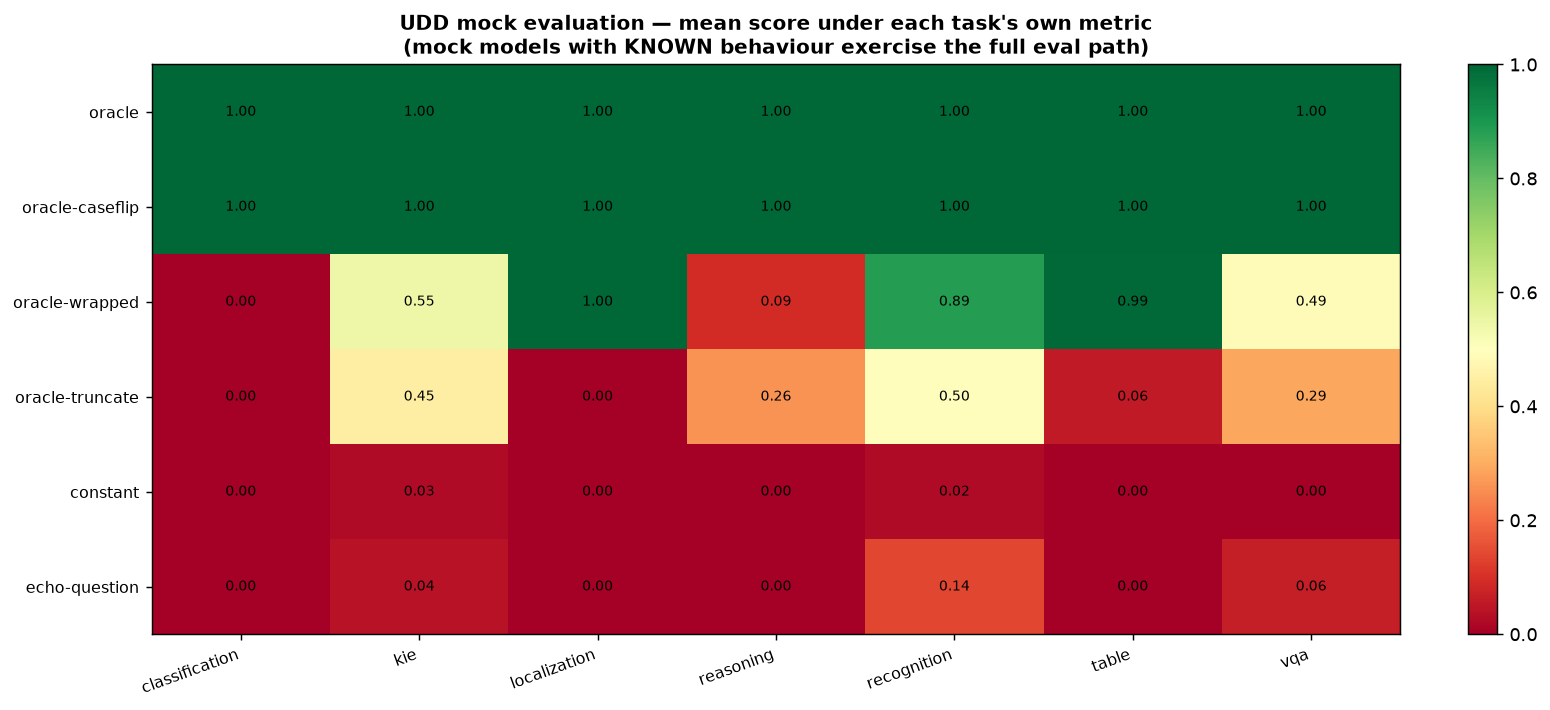

In [6]:
r = subprocess.run([sys.executable, "scripts/mock_eval_udd.py"], cwd=ROOT,
                   capture_output=True, text=True)
print(r.stdout[-300:]); assert r.returncode == 0, "mock eval sanity failed"
from IPython.display import Image as IPyImage, display
display(IPyImage(str(ROOT / "docs/report/figures/udd_mock_eval.png")))

## 6. Run the arms for real (GPU required — skipped automatically without one)

Trains LoRA on each composed arm and evaluates BOTH the synthetic probe suite and the UDD public
heldout; results land in `docs/results/udd_ablation_results.json` under `U-<arm>`.

In [7]:
import importlib.util
has_gpu = False
if importlib.util.find_spec("torch"):
    import torch; has_gpu = torch.cuda.is_available()
if has_gpu:
    subprocess.run([sys.executable, "scripts/run_udd_ablation.py", "--arm", "A1", "A2",
                    "--count", "300", "--steps", "300"], cwd=ROOT, check=True)
else:
    print("no GPU — skipping training. On a T4/Colab, run:")
    print("  python scripts/run_udd_ablation.py --arm A1 A2 --count 300 --steps 300")

no GPU — skipping training. On a T4/Colab, run:
  python scripts/run_udd_ablation.py --arm A1 A2 --count 300 --steps 300


## 7. Read results (once the GPU runs land)

In [8]:
res = ROOT / "docs/results/udd_ablation_results.json"
if res.exists():
    doc = json.loads(res.read_text())
    for model, arms in doc.get("models", {}).items():
        for arm, payload in arms.items():
            cap = payload.get("probes", {}).get("capability", {}).get("score")
            print(f"{model:18} {arm:22} capability={cap}")
else:
    print("no results yet — section 6 (GPU) has not run; the wiring above is verified regardless.")

no results yet — section 6 (GPU) has not run; the wiring above is verified regardless.
